In [7]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import DistilBertTokenizer, DistilBertModel
from tqdm import tqdm
import matplotlib.pyplot as plt

In [8]:
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.projection = nn.Linear(512, embed_dim)
    
    def forward(self, x):
        features = self.backbone(x)
        features = features.squeeze(-1).squeeze(-1)
        embedding = self.projection(features)
        return embedding

In [9]:
class TextEncoder(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
        self.backbone = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.projection = nn.Linear(768, embed_dim)
    
    def forward(self, texts, device):
        tokens = self.tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        )
        # GPU FIX — move tokens to same device as model
        tokens = {k: v.to(device) for k, v in tokens.items()}
        output = self.backbone(**tokens)
        cls_embedding = output.last_hidden_state[:, 0, :]
        embedding = self.projection(cls_embedding)
        return embedding

In [10]:
class Flickr30kDataset(Dataset):
    def __init__(self, csv_path, images_path, transform=None):
        self.df = pd.read_csv(csv_path, sep='|')
        self.df.columns = self.df.columns.str.strip()
        self.df['comment'] = self.df['comment'].str.strip()
        self.images_path = images_path
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row['image_name']
        caption = row['comment']
        image_path = os.path.join(self.images_path, image_name)
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, caption

In [11]:
csv_path = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv'
images_path = '/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images/'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = Flickr30kDataset(csv_path, images_path, transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

print(f"Total samples: {len(dataset)}")
images, captions = next(iter(dataloader))
print(f"Batch shape: {images.shape}")
print(f"Sample caption: {captions[0]}")

Total samples: 158915
Batch shape: torch.Size([64, 3, 224, 224])
Sample caption: There is a competitive game on rollerskates , the teams seem to be chasing another player .


In [12]:
class CLIPModel(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim)
        self.text_encoder = TextEncoder(embed_dim)
        self.temperature = nn.Parameter(torch.ones([]) * 0.07)
    
    def forward(self, images, texts):
        device = images.device  # get device from images tensor
        image_embeddings = self.image_encoder(images)
        text_embeddings = self.text_encoder(texts, device)  # pass device
        image_embeddings = F.normalize(image_embeddings, dim=-1)
        text_embeddings = F.normalize(text_embeddings, dim=-1)
        return image_embeddings, text_embeddings, self.temperature

In [13]:
# Test full forward pass
model = CLIPModel(embed_dim=256)
model.eval()

with torch.no_grad():
    img_emb, txt_emb, temp = model(images, list(captions))

print(f"Image embeddings: {img_emb.shape}")
print(f"Text embeddings: {txt_emb.shape}")
print(f"Temperature: {temp.item():.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s] 


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Image embeddings: torch.Size([64, 256])
Text embeddings: torch.Size([64, 256])
Temperature: 0.0700


In [14]:
def infonce_loss(image_embeddings, text_embeddings, temperature):
    """
    InfoNCE / CLIP contrastive loss.
    image_embeddings: (N, embed_dim) — already L2 normalized
    text_embeddings:  (N, embed_dim) — already L2 normalized
    temperature:      learnable scalar parameter
    """
    N = image_embeddings.shape[0]
    
    # Similarity matrix: (N, N)
    # logits[i][j] = similarity between image i and text j
    logits = (image_embeddings @ text_embeddings.T) / temperature.exp()
    
    # Ground truth: diagonal is the correct pair
    labels = torch.arange(N, device=image_embeddings.device)
    
    # Symmetric loss: image→text + text→image
    loss_i2t = F.cross_entropy(logits, labels)        # each image finds its text
    loss_t2i = F.cross_entropy(logits.T, labels)      # each text finds its image
    
    loss = (loss_i2t + loss_t2i) / 2
    return loss

In [15]:
# After your existing forward pass test cell:
loss = infonce_loss(img_emb, txt_emb, model.temperature)
print(f"InfoNCE Loss: {loss.item():.4f}")
# Expected: ~log(64) ≈ 4.15 for a random untrained model (batch size 64)

InfoNCE Loss: 4.1591


In [16]:
# GPU Setup & Model Initialization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# initialize model and move to GPU
model = CLIPModel(embed_dim=256).to(device)

# optimizer — Adam with small learning rate for fine-tuning
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# scheduler — reduces LR by half every 3 epochs
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.5
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 77,867,585


In [17]:
# InfoNCE Loss Function

def infonce_loss(image_embeddings, text_embeddings, temperature):
    N = image_embeddings.shape[0]
    
    # N×N similarity matrix
    logits = (image_embeddings @ text_embeddings.T) / temperature.exp()
    
    # correct match for image i is text i → diagonal
    labels = torch.arange(N, device=image_embeddings.device)
    
    # symmetric loss — both directions
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    
    return (loss_i2t + loss_t2i) / 2

In [18]:
# Training Loop

import os
EPOCHS = 5
LOG_EVERY = 100
SAVE_DIR = "/kaggle/working/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    num_batches = 0
    
    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (images, captions) in enumerate(loop):
        # move images to GPU
        images = images.to(device)
        captions = [str(c) for c in captions]
        
        # forward pass
        img_emb, txt_emb, temp = model(images, captions)
        
        # compute loss
        loss = infonce_loss(img_emb, txt_emb, temp)
        
        # backward pass
        optimizer.zero_grad()  # clear old gradients
        loss.backward()        # compute new gradients
        optimizer.step()       # update weights
        
        # logging
        epoch_loss += loss.item()
        num_batches += 1
        loss_history.append(loss.item())
        
        # update progress bar
        loop.set_postfix(loss=f"{loss.item():.4f}")
        
        if batch_idx % LOG_EVERY == 0:
            print(f"Epoch {epoch+1} | Step {batch_idx} | Loss: {loss.item():.4f}")
    
    # average loss this epoch
    avg_loss = epoch_loss / num_batches
    print(f"\nEpoch {epoch+1} complete | Avg Loss: {avg_loss:.4f}")
    
    # update learning rate
    scheduler.step()
    
    # save checkpoint
    checkpoint_path = os.path.join(SAVE_DIR, f"clip_epoch_{epoch+1}.pt")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")

print("\nTraining complete!")

Epoch 1/5:   0%|          | 1/2484 [00:03<2:24:26,  3.49s/it, loss=4.1621]

Epoch 1 | Step 0 | Loss: 4.1621


Epoch 1/5:   4%|▍         | 101/2484 [00:53<17:06,  2.32it/s, loss=3.6174]

Epoch 1 | Step 100 | Loss: 3.6174


Epoch 1/5:   8%|▊         | 201/2484 [01:37<16:38,  2.29it/s, loss=3.5966]

...

Epoch 5 | Step 2300 | Loss: 2.0678


Epoch 5/5:  97%|█████████▋| 2401/2484 [17:15<00:37,  2.19it/s, loss=2.1076]

Epoch 5 | Step 2400 | Loss: 2.1076


Epoch 5/5: 100%|██████████| 2484/2484 [17:51<00:00,  2.32it/s, loss=0.1794]



Epoch 5 complete | Avg Loss: 2.1784
Checkpoint saved: /kaggle/working/checkpoints/clip_epoch_5.pt

Training complete!


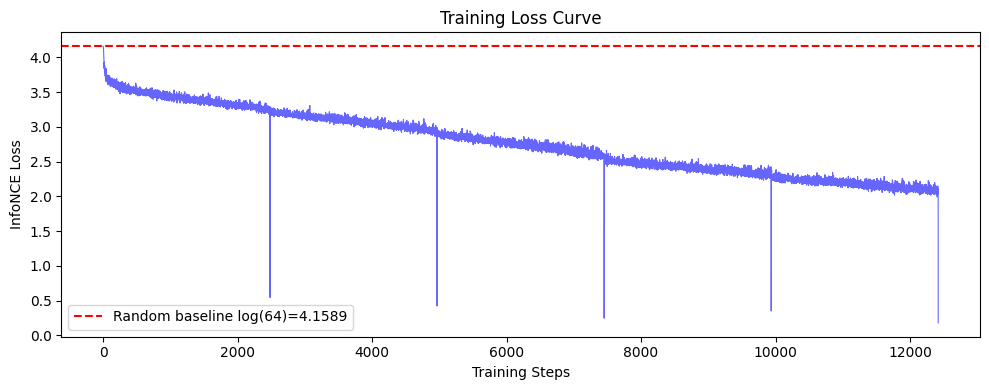

Loss curve saved.


In [19]:
# Loss Curve Visualization

plt.figure(figsize=(10, 4))
plt.plot(loss_history, alpha=0.6, color='blue', linewidth=0.8)
plt.xlabel("Training Steps")
plt.ylabel("InfoNCE Loss")
plt.title("Training Loss Curve")
plt.axhline(y=4.1589, color='red', linestyle='--', 
            label=f'Random baseline log(64)=4.1589')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=150)
plt.show()
print("Loss curve saved.")

In [20]:
# Recall@K Evaluation

def evaluate_recall(model, dataset, device, num_samples=1000):
    model.eval()
    
    # use subset for faster evaluation
    indices = list(range(min(num_samples, len(dataset))))
    
    all_image_embs = []
    all_text_embs  = []
    
    print("Computing embeddings for evaluation...")
    
    with torch.no_grad():
        for idx in tqdm(indices):
            image, caption = dataset[idx]
            
            # image embedding
            image = image.unsqueeze(0).to(device)
            img_emb = model.image_encoder(image)
            img_emb = F.normalize(img_emb, dim=-1)
            all_image_embs.append(img_emb.cpu())
            
            # text embedding
            txt_emb = model.text_encoder([caption], device)
            txt_emb = F.normalize(txt_emb, dim=-1)
            all_text_embs.append(txt_emb.cpu())
    
    # stack into matrices
    image_embs = torch.cat(all_image_embs, dim=0)  # [N, 256]
    text_embs  = torch.cat(all_text_embs,  dim=0)  # [N, 256]
    
    # similarity matrix [N, N]
    sim_matrix = image_embs @ text_embs.T
    
    def recall_at_k(sim_matrix, k):
        N = sim_matrix.shape[0]
        correct = 0
        for i in range(N):
            top_k = sim_matrix[i].topk(k).indices
            if i in top_k:
                correct += 1
        return correct / N
    
    # Image → Text retrieval
    r1_i2t  = recall_at_k(sim_matrix, 1)
    r5_i2t  = recall_at_k(sim_matrix, 5)
    r10_i2t = recall_at_k(sim_matrix, 10)
    
    # Text → Image retrieval
    r1_t2i  = recall_at_k(sim_matrix.T, 1)
    r5_t2i  = recall_at_k(sim_matrix.T, 5)
    r10_t2i = recall_at_k(sim_matrix.T, 10)
    
    print(f"\n{'='*40}")
    print(f"Recall@K Evaluation ({num_samples} samples)")
    print(f"{'='*40}")
    print(f"Image → Text:  R@1={r1_i2t:.3f}  R@5={r5_i2t:.3f}  R@10={r10_i2t:.3f}")
    print(f"Text → Image:  R@1={r1_t2i:.3f}  R@5={r5_t2i:.3f}  R@10={r10_t2i:.3f}")
    print(f"{'='*40}")
    
    return sim_matrix

sim_matrix = evaluate_recall(model, dataset, device, num_samples=1000)

Computing embeddings for evaluation...


100%|██████████| 1000/1000 [00:13<00:00, 71.59it/s]



Recall@K Evaluation (1000 samples)
Image → Text:  R@1=0.174  R@5=0.692  R@10=0.853
Text → Image:  R@1=0.151  R@5=0.725  R@10=0.862


Computing embeddings for t-SNE...


100%|██████████| 200/200 [00:02<00:00, 72.78it/s]


Running t-SNE (this takes ~1 min)...


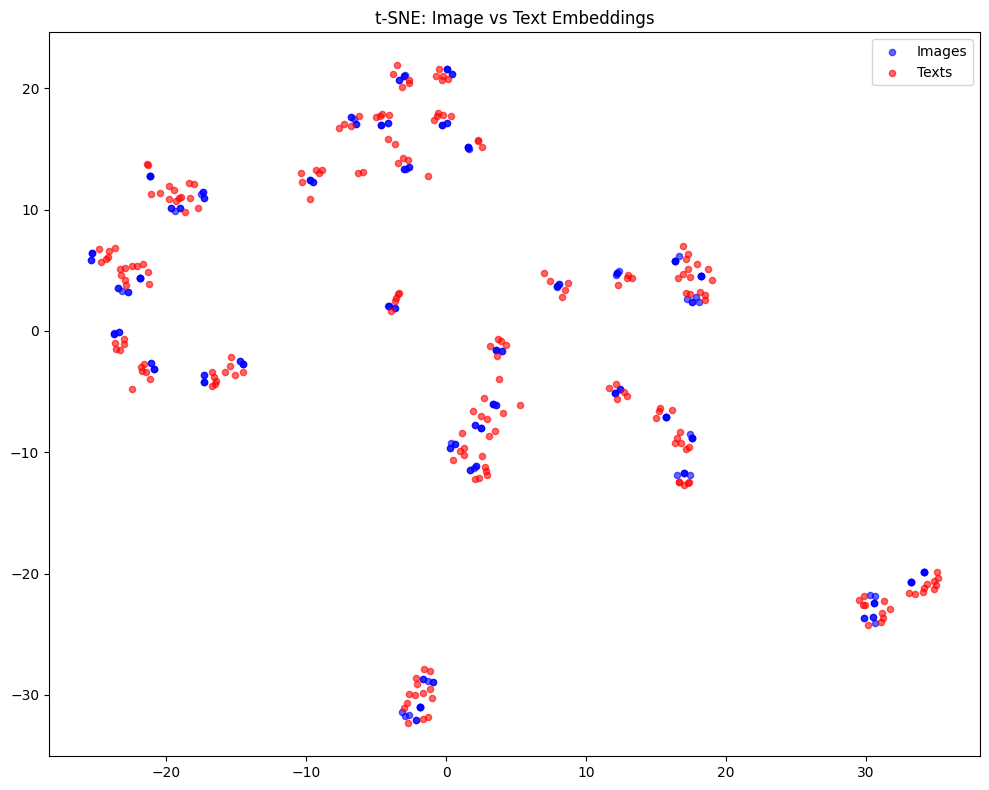

t-SNE saved.


In [34]:
# t-SNE Visualization

from sklearn.manifold import TSNE

model.eval()
NUM_SAMPLES = 200

all_embs   = []
all_labels = []  # 0 = image, 1 = text

print("Computing embeddings for t-SNE...")

with torch.no_grad():
    for idx in tqdm(range(NUM_SAMPLES)):
        image, caption = dataset[idx]
        
        image = image.unsqueeze(0).to(device)
        img_emb = model.image_encoder(image)
        img_emb = F.normalize(img_emb, dim=-1)
        all_embs.append(img_emb.cpu().numpy())
        all_labels.append(0)  # image
        
        txt_emb = model.text_encoder([caption], device)
        txt_emb = F.normalize(txt_emb, dim=-1)
        all_embs.append(txt_emb.cpu().numpy())
        all_labels.append(1)  # text

all_embs   = np.vstack(all_embs)    # [400, 256]
all_labels = np.array(all_labels)

print("Running t-SNE (this takes ~1 min)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embs_2d = tsne.fit_transform(all_embs)

# plot
plt.figure(figsize=(10, 8))
plt.scatter(embs_2d[all_labels==0, 0], 
            embs_2d[all_labels==0, 1],
            c='blue', alpha=0.6, s=20, label='Images')
plt.scatter(embs_2d[all_labels==1, 0], 
            embs_2d[all_labels==1, 1],
            c='red', alpha=0.6, s=20, label='Texts')
plt.title("t-SNE: Image vs Text Embeddings")
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/tsne.png', dpi=150)
plt.show()
print("t-SNE saved.")

In [37]:
# Hard Negative Mining — Comparison Experiment

def hard_negative_infonce_loss(image_embeddings, text_embeddings, temperature, top_k=10):
    N = image_embeddings.shape[0]
    
    sim_matrix = image_embeddings @ text_embeddings.T
    logits = sim_matrix / temperature.exp()
    labels = torch.arange(N, device=image_embeddings.device)
    
    # mask diagonal to find hard negatives
    mask = torch.eye(N, dtype=torch.bool, device=image_embeddings.device)
    sim_negatives = sim_matrix.masked_fill(mask, -float('inf'))
    
    # top_k hardest negatives per row
    k = min(top_k, N - 1)
    _, hard_neg_idx = sim_negatives.topk(k, dim=1)
    
    # keep only diagonal + hard negatives
    hard_mask = mask.clone()
    hard_mask.scatter_(1, hard_neg_idx, True)
    
    # easy negatives → -inf
    logits_hard = logits.masked_fill(~hard_mask, -float('inf'))
    
    # symmetric loss
    loss_i2t = F.cross_entropy(logits_hard, labels)
    loss_t2i = F.cross_entropy(logits_hard.T, labels)
    
    return (loss_i2t + loss_t2i) / 2

In [38]:
# load from BEST standard model (epoch 5)
model_hn = CLIPModel(embed_dim=256).to(device)
checkpoint_hn = torch.load(
    '/kaggle/working/checkpoints/clip_epoch_5.pt',
    weights_only=False
)
model_hn.load_state_dict(checkpoint_hn['model_state_dict'])
print(f"Loaded standard model epoch 5 as HN starting point")
print(f"Starting loss should be around 2.0")

optimizer_hn = torch.optim.Adam(model_hn.parameters(), lr=5e-5)
scheduler_hn = torch.optim.lr_scheduler.StepLR(
    optimizer_hn, step_size=2, gamma=0.5
)

EPOCHS_HN = 3
LOG_EVERY = 100
loss_history_hn = []

for epoch in range(EPOCHS_HN):
    model_hn.train()
    epoch_loss = 0
    num_batches = 0

    loop = tqdm(dataloader, desc=f"HN Epoch {epoch+1}/{EPOCHS_HN}")

    for batch_idx, (images, captions) in enumerate(loop):
        images = images.to(device)
        captions = [str(c) for c in captions]

        img_emb, txt_emb, temp = model_hn(images, captions)
        loss = hard_negative_infonce_loss(img_emb, txt_emb, temp, top_k=10)

        optimizer_hn.zero_grad()
        loss.backward()
        optimizer_hn.step()

        epoch_loss += loss.item()
        num_batches += 1
        loss_history_hn.append(loss.item())
        loop.set_postfix(loss=f"{loss.item():.4f}")

        if batch_idx % LOG_EVERY == 0:
            print(f"HN Epoch {epoch+1} | Step {batch_idx} | Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / num_batches
    print(f"\nHN Epoch {epoch+1} complete | Avg Loss: {avg_loss:.4f}")
    scheduler_hn.step()

    checkpoint_path = os.path.join(SAVE_DIR, f"clip_hn_epoch_{epoch+1}.pt")
    torch.save({
        'epoch': epoch+1,
        'model_state_dict': model_hn.state_dict(),
        'optimizer_state_dict': optimizer_hn.state_dict(),
        'loss': avg_loss,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")

print("\nHard Negative Training Complete!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded standard model epoch 5 as HN starting point
Starting loss should be around 2.0


HN Epoch 1/3:   0%|          | 1/2484 [00:01<48:33,  1.17s/it, loss=1.4605]

HN Epoch 1 | Step 0 | Loss: 1.4605


...

HN Epoch 3 | Step 2300 | Loss: 0.7712


HN Epoch 3/3:  97%|█████████▋| 2401/2484 [17:17<00:37,  2.22it/s, loss=0.8635]

HN Epoch 3 | Step 2400 | Loss: 0.8635


HN Epoch 3/3: 100%|██████████| 2484/2484 [17:52<00:00,  2.32it/s, loss=0.1363]



HN Epoch 3 complete | Avg Loss: 0.8882
Checkpoint saved: /kaggle/working/checkpoints/clip_hn_epoch_3.pt

Hard Negative Training Complete!


In [44]:
# Compare Recall@K — Standard vs Hard Negative
print("Evaluating Standard Model (epoch 5)...")
sim_std = evaluate_recall(model, dataset, device, num_samples=1000)

print("\nEvaluating Hard Negative Model...")
sim_hn = evaluate_recall(model_hn, dataset, device, num_samples=1000)

Evaluating Standard Model (epoch 5)...
Computing embeddings for evaluation...


100%|██████████| 1000/1000 [00:13<00:00, 76.10it/s]



Recall@K Evaluation (1000 samples)
Image → Text:  R@1=0.174  R@5=0.692  R@10=0.853
Text → Image:  R@1=0.151  R@5=0.725  R@10=0.862

Evaluating Hard Negative Model...
Computing embeddings for evaluation...


100%|██████████| 1000/1000 [00:12<00:00, 79.12it/s]



Recall@K Evaluation (1000 samples)
Image → Text:  R@1=0.186  R@5=0.837  R@10=0.946
Text → Image:  R@1=0.168  R@5=0.848  R@10=0.945
